In [45]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd


#échauffement

a = np.array([1,2,3])
print(a[:,None])
print(a[None, :])
print(a[:, None] - a[None, :])

b = np.array([[1,2,3],[1,2,3]])
print(b)
print(b[:, None,:])
print(b[:,:,None])
print(b[:, None,:] - b[:,:,None])


[[1]
 [2]
 [3]]
[[1 2 3]]
[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]
[[1 2 3]
 [1 2 3]]
[[[1 2 3]]

 [[1 2 3]]]
[[[1]
  [2]
  [3]]

 [[1]
  [2]
  [3]]]
[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]]


In [46]:
# initialisation aléatoire
# les bornes pour le tirage au sort initial

mass_max = 3.    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.
speed_max = 1.

def init_problem(N):
    masses = np.random.uniform(0.1,mass_max,N) #on tire N fois une masse entre 0.1 et mass_max au hasard
    positions = np.random.uniform(np.array([[x_min],[y_min]]),np.array([[x_max],[y_max]]),(2,N)) #idem avec un tableau de dim (2,N) pour stocker les x d'un côté et les y de l'autre
    speeds = np.random.uniform(-1,1,(2,N)) #idem que ci-dessus
    return masses,positions,speeds

print(init_problem(4))

#test de init_problem

masses, positions, speeds = init_problem(10)

try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("OK")
except:
    print("KO") #le test fonctionne !

(array([1.29665097, 2.02379534, 0.55324189, 0.80128823]), array([[ 8.3420392 , -3.55407824, -6.29924875,  3.58975782],
       [ 1.20250979, -2.79669075,  2.61295372, -0.96484096]]), array([[ 0.57184156, -0.32107394, -0.50121826, -0.89321675],
       [-0.95894492,  0.86673445,  0.92781779, -0.27036042]]))
OK


In [47]:
#fonction commode donnée

def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds

masses, positions, speeds = init3()
print(positions.shape)


(2, 3)


In [48]:
#Les forces

def forces(masses, positions, G=1.0):
    diff = positions[:,None,:] - positions[:,:, None] #OK car position.shape = (2,3) et cf échauffement
    distance = np.linalg.norm(diff,axis = 0)
    np.fill_diagonal(distance,np.inf) #la division par l'infini donne ainsi une force nulle d'une particule sur elle-même
    coeff = G * masses[:, None] * masses[None, :] / distance**3
    force = np.sum(coeff[None, :, :] * diff, axis = 2)
    return force
print(forces(masses,positions,1))

[[ 0.         -0.12257258  0.12257258]
 [ 0.         -0.02451452  0.02451452]]


In [50]:
#Le simulateur

def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    dim, N = positions.shape
    trajectoire = np.empty((nb_steps,dim,N))
    trajectoire[0] = positions #initialisation
    for i in range(1, nb_steps):
        accel = forces(masses,positions,G=1.0)/masses[None,:] #broadcasting ok
        speeds = speeds + accel * dt #on utilise la méthode d'euler pour avoir les vitesses suivantes
        positions = positions + speeds * dt #idem
        trajectoire[i] = positions #on remplit trajectoire
    return trajectoire

#test de simulate

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")

print(s[1]) #le test fonctionne !

shape OK
[[ 0.          4.89877427 -4.89877427]
 [ 0.          0.99975485 -0.99975485]]


In [51]:
#Dessiner

def draw(simulation, masses, colors=None, scale=10.):
    nb_steps, dim, N = simulation.shape

    if colors is None :
        colors = np.random.uniform(0.3, 1, size=(N, 3)) #couleurs au hasard ; dans un tableau de dimension 3 pour RGB
    fig, ax = plt.subplots() #on crée le graph
    for i in range(N):
        t = simulation[:,:,i].T #on suit l'indication
        ax.scatter(*t, color=colors[i],s=(masses[i] * scale)) #on suit l'indication

    return ax

# for convenience

colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255

<Axes: >

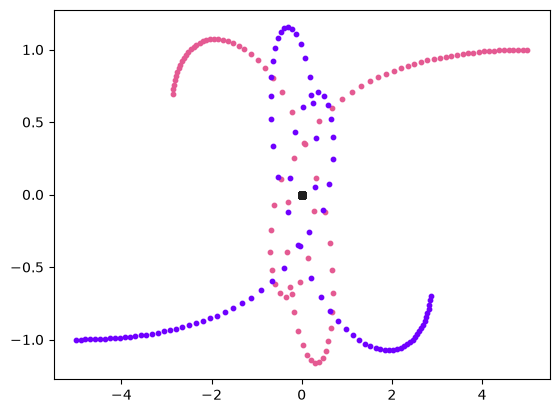

In [44]:
#On assemble le tout
masses, positions, speeds = init3()
draw(simulate(masses, positions, speeds), masses, colors3)


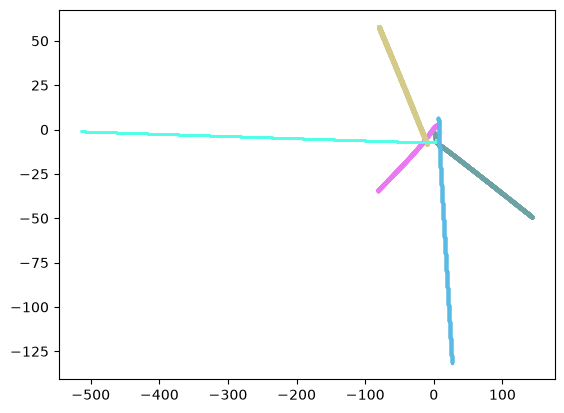

In [52]:
#Scénario plus compliqué

m5, p5, s5 = init_problem(5)
sim5 = simulate(m5, p5, s5, nb_steps=1000)
draw(sim5, m5, scale=3);
plt.savefig("random5.png")
